In [23]:
import numpy as np


print(np.linspace(1, 12, 10, dtype=int) )

# only heads that divide 128: 1,2,4,8,16,32,64,128
n_head  = np.array([1, 2, 4, 8, 16, 32, 64, 128])  # all divide 128 ✓

print(np.linspace(64, 512, 10, dtype=int)
                // 32 * 32)    

batch_size=[4,8,16,32]




[ 1  2  3  4  5  7  8  9 10 12]
[ 64  96 160 192 256 288 352 384 448 512]


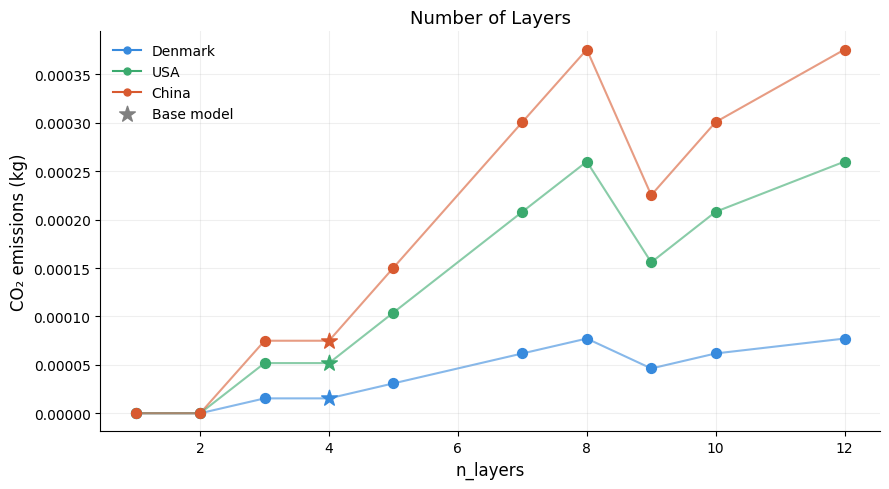

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../results_train.csv')
layers = df['N_LAYER'].tolist()
kwh    = df['emission'].tolist()

BASE = 4

GRIDS = {
    'Denmark': (0.114, '#378ADD'),
    'USA':     (0.384, '#3BAA6E'),
    'China':   (0.555, '#D85A30'),
}

fig, ax = plt.subplots(figsize=(9, 5))

for country, (factor, color) in GRIDS.items():
    co2 = [e * factor for e in kwh]

    ax.plot(layers, co2, color=color, linewidth=1.5, alpha=0.6, zorder=1)

    for l, e in zip(layers, co2):
        if l == BASE:
            ax.scatter(l, e, color=color, s=140, zorder=3, marker='*')
        else:
            ax.scatter(l, e, color=color, s=50, zorder=2, marker='o')

    # legend entries
    ax.plot([], [], color=color, linewidth=1.5, marker='o', markersize=5, label=country)

# single star entry in legend for base model
ax.scatter([], [], color='gray', s=140, marker='*', label=f'Base model')

ax.set_xlabel('n_layers', fontsize=12)
ax.set_ylabel('CO₂ emissions (kg)', fontsize=12)
ax.set_title('Number of Layers', fontsize=13)
ax.legend(frameon=False, fontsize=10)
ax.grid(True, alpha=0.2)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('emissions_by_country.png', dpi=150)
plt.show()